# Radionica 1 — Uvod u podatke i vizualizaciju
### GirlTHing ML/Data Science blok

Danas radimo sa datasetom "stvarnih" oglasa za prodaju stanova u Tuzli. Cilj nije da napamet znate pandas naredbe — cilj je da naučite **proces** koji možete ponoviti na bilo kom dataset-u:

**struktura → kvalitet podataka → jedna varijabla → dvije varijable → grupe/segmenti → zaključak**

Radite u paru. Kad naiđete na `# TODO`, to je mjesto gdje vi dovršavate kod — sve ostalo je već pripremljeno da radi.

## Korak 0 — Učitavanje podataka

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

URL = "https://drive.google.com/uc?export=download&id=152Ff9y6aQsctxMRNEZqiiy9wsFH6Tkdu"
df = pd.read_csv(URL)



In [6]:
# TODO: prikaži prvih 5 redova
df.head(5)

,oglas_id,naselje,kvadratura_m2,sprat,broj_soba,godina_izgradnje,stanje,balkon,parking,cijena_km,datum_oglasa
0,72452589,Dragodol,29.0,4.0,1.0,NaN,Namješten,da,ne,119500.0,15.08.2026
1,74346041,Irac,30.0,4.0,1.0,NaN,Useljivo,da,da,144200.0,02.08.2026
2,73606572,Bukinje,77.0,6.0,3.0,1984.0,Namješten,da,ne,253800.0,14.06.2026
3,78507134,Irac,90.0,1.0,4.0,1983.0,Useljivo,da,da,340300.0,13.06.2026
4,70023087,Kreka,75.0,7.0,3.0,2013.0,Useljivo,ne,ne,339500.0,04.05.2026


## Korak 1 — Struktura dataset-a
Prije bilo čega drugog: koliko redova/kolona imamo, koji su tipovi podataka, i koliko toga uopšte nedostaje?

In [13]:
# TODO: ispiši oblik dataset-a (broj redova, broj kolona)
print("Broj redova i kolona:", df.shape)

# TODO: ispiši info o tipovima podataka i broju ne-null vrijednosti po koloni
df.isna().sum()

Broj redova i kolona: (668, 11)


oglas_id              0
naselje               3
kvadratura_m2        15
sprat                48
broj_soba             3
godina_izgradnje    272
stanje                3
balkon                4
parking               3
cijena_km             3
datum_oglasa          0
dtype: int64

In [11]:
# TODO: deskriptivna statistika za sve kolone (i brojevne i tekstualne)
df.describe(include='all')

,oglas_id,naselje,kvadratura_m2,sprat,broj_soba,godina_izgradnje,stanje,balkon,parking,cijena_km,datum_oglasa
count,6.680000e+02,665,653,620,665.000000,396,665,664,665,665,668
unique,NaN,62,131,18,NaN,76,7,2,2,610,177
top,NaN,Centar,58.0,3.0,NaN,1998.0,Useljivo,da,ne,238100.0,13.06.2026
freq,NaN,90,15,67,NaN,11,153,494,409,3,9
mean,7.505885e+07,NaN,NaN,NaN,2.481203,NaN,NaN,NaN,NaN,NaN,NaN
std,2.916684e+06,NaN,NaN,NaN,1.110611,NaN,NaN,NaN,NaN,NaN,NaN
min,7.000992e+07,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,7.244981e+07,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,7.517312e+07,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,NaN
75%,7.749535e+07,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN


## Korak 2 — Kvalitet podataka (čišćenje)

Ovaj dataset ima nekoliko tipičnih problema pravih oglasa. Za svaki problem koji riješite, **imenujte ga naglas paru** — nedostajuća vrijednost? Duplikat? Pogrešan tip? Outlier?

### 2a — Koliko nedostaje po koloni?

In [12]:
# TODO: prebroji nedostajuće vrijednosti po koloni
df.isnull().sum()

oglas_id              0
naselje               3
kvadratura_m2        15
sprat                48
broj_soba             3
godina_izgradnje    272
stanje                3
balkon                4
parking               3
cijena_km             3
datum_oglasa          0
dtype: int64

### 2b — Cijena je upisana kao tekst u više formata
Pogledajte kolonu `cijena_km` — neki redovi su brojevi, neki tekst poput `"85.000 KM"` ili `"85 000"`. Napravite funkciju koja sve te formate pretvara u čist broj (float).

In [14]:
def parse_cijena(v):
    if pd.isna(v):
        return np.nan
    s = str(v).upper().replace('KM', '').strip().replace(' ', '')
    # Pažnja: '.' i ',' mogu biti separator hiljada (128.100 = 128100) ILI
    # obična decimala kad broj već dolazi kao npr. 98900.0 (tj. .0 na kraju).
    # TODO: ako string završava na '.0', to je decimala - ukloni samo taj sufiks.
    # Inače, ukloni SVE tačke i zareze (to su separatori hiljada).
    if s.endswith('.'):
        s = s[:-2]
    else:
        s = s.replace('.', '').replace(',', '')
    try:
        return float(s)
    except ValueError:
        return np.nan

# TODO: primijeni funkciju na kolonu 'cijena_km' i sačuvaj u novu kolonu 'cijena_km_clean'
df['cijena_km_clean'] = df['cijena_km'].apply(parse_cijena)
df[['cijena_km', 'cijena_km_clean']].sample(8)

,cijena_km,cijena_km_clean
44,209200.0,2092000.0
620,236800.0,2368000.0
7,259700.0,2597000.0
115,381900.0,3819000.0
537,154000.0,1540000.0
430,313100.0,3131000.0
593,98100.0,981000.0
432,128900.0,1289000.0


### 2c — Kvadratura kao tekst, nekonzistentni nazivi naselja
Slična priča: `kvadratura_m2` ponegdje ima `"45 m2"` umjesto broja, a `naselje` ima velika/mala slova, razmake i dodatke poput `"- Tuzla"`.

In [15]:
def parse_kvadratura(v):
    if pd.isna(v):
        return np.nan
    s = str(v).lower().replace('m2', '').replace('m²', '').strip()
    try:
        return float(s)
    except ValueError:
        return np.nan

def clean_naselje(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip()
    # TODO: ukloni dodatak '- Tuzla' ako postoji
    s = s.replace('- Tuzla', '')
    # TODO: ujednači veliko/malo slovo (hint: .title())
    return s.strip().title()

df['kvadratura_clean'] = df['kvadratura_m2'].apply(parse_kvadratura)
df['naselje_clean'] = df['naselje'].apply(clean_naselje)
df['naselje_clean'].value_counts()

naselje_clean
Centar            102
Slavinovići        60
Stupine            58
Mejdan             56
Kreka              53
Sjenjak            45
Simin Han          39
Bukinje            37
Brčanska Malta     37
Dragodol           36
Solina             33
Zlokovac           27
Gornja Tuzla       27
Šićki Brod         26
Irac               20
Miladije            9
Name: count, dtype: int64

### 2d — Sprat kao tekst ("Prizemlje") i godina kao raspon ("1970-1979")
Dva dodatna, vrlo autentična problema iz stvarnih OLX oglasa: prizemlje se ponekad piše riječju umjesto brojem 0, a godina izgradnje ponekad dolazi kao raspon decenije umjesto tačne godine.

In [16]:
import re

def parse_sprat(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower()
    # TODO: ako je tekst 'prizemlje', to je sprat 0
    if s == 'prizemlje' or s == 'Prizemlje'  :
        return 0
    try:
        return float(s)
    except ValueError:
        return np.nan

def parse_godina(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip()
    # TODO: ako string sadrži '-' ili 'do', to je raspon (npr. '1970-1979') - uzmi sredinu kao procjenu
    if '-' in s or 'do' in s:
        nums = [int(x) for x in re.findall(r'\d{4}', s)]
        return float(np.mean(nums)) if nums else np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

# TODO: primijeni obje funkcije
df['sprat_clean'] = df['sprat'].apply(parse_sprat)
df['godina_clean'] = df['godina_izgradnje'].apply(parse_godina)
df[['sprat', 'sprat_clean', 'godina_izgradnje', 'godina_clean']].sample(8)

,sprat,sprat_clean,godina_izgradnje,godina_clean
184,2.0,2.0,1990.0,1990.0
84,6.0,6.0,1980.0,1980.0
571,1.0,1.0,1985.0,1985.0
225,1.0,1.0,1969.0,1969.0
82,2.0,2.0,NaN,NaN
414,10.0,10.0,NaN,NaN
637,5.0,5.0,2022.0,2022.0
254,4.0,4.0,1977.0,1977.0


### 2e — Kolona `stanje` zapravo miješa dva različita pojma — ovdje VI pišete funkciju (uz pomoć AI-ja)

Pogledajte pažljivije moguće vrijednosti u koloni `stanje`:

`Useljivo, Renoviran, Potrebna renovacija, Dobro stanje, Nov, Namješten, Nenamješten`

Primjećujete problem? Ova kolona miješa **fizičko stanje stana** (nov, renoviran, treba renovaciju...) i **namještenost** (namješten/nenamješten) — dvije different stvari nabačene u jednu kolonu. Ovo je vrlo česta situacija u stvarnim podacima.

**Za razliku od prethodnih koraka, ovdje nema praznina za popuniti — napišite funkcije od nule, uz pomoć AI alata (Copilot, ChatGPT, šta god koristite):**

1. Funkcija `parse_fizicko_stanje(v)` — iz `stanje` izdvaja SAMO fizičko stanje (`Nov`, `Renoviran`, `Potrebna renovacija`, `Useljivo`, `Dobro stanje`); za `Namješten`/`Nenamješten` (i za NaN) vraća `NaN`, jer ti redovi ne govore ništa o fizičkom stanju.
2. Funkcija `parse_namjestenost(v)` — izdvaja SAMO namještenost (`Namješten`/`Nenamješten`); za sve ostalo vraća `NaN`.
3. Primijenite obje na kolonu `stanje`, sačuvajte kao nove kolone `fizicko_stanje` i `namjestenost_clean`.
4. Provjerite: koliko NaN vrijednosti ima svaka nova kolona? Da li vam se to čini logično?

**Kako iskoristiti AI:** opišite mu problem svojim riječima ("imam pandas kolonu koja ..."), pogledajte šta predloži, pa **provjerite** da li stvarno radi na par primjera prije nego nastavite dalje — AI ponekad pogriješi (npr. zaboravi NaN, ili pogrešno kategoriše neku vrijednost).

In [18]:
# Podsjetnik na moguće vrijednosti u 'stanje':
print(df['stanje'].value_counts(dropna=False))

# Probaj sama, uz pomoć AI-ja:
def parse_fizicko_stanje(v):
  if pd.isna(v):
    return np.nan

  fizicka_stanja = [
      'Nov',
      'Renoviran',
      'Potrebna renovacija',
      'Useljivo',
      'Dobro stanje',
  ]
  v_clean = str(v).strip()

  if v_clean in fizicka_stanja:
    return v_clean
  return np.nan


def parse_namjestenost(v):
  if pd.isna(v):
    return np.nan

  namjestenost_stanja = ['Namješten', 'Nenamješten','Namjesten','Nenamjesten']
  v_clean = str(v).strip()

  if v_clean in namjestenost_stanja:
    return v_clean
  return np.nan

df['fizicko_stanje'] = df['stanje'].apply(parse_fizicko_stanje)
df['namjestenost_clean'] = df['stanje'].apply(parse_namjestenost)

# Provjera:
print(df['fizicko_stanje'].isna().sum())
print(df['namjestenost_clean'].isna().sum())


stanje
Useljivo               153
Renoviran              110
Potrebna renovacija    101
Dobro stanje            83
Namješten               82
Nov                     73
Nenamješten             63
NaN                      3
Name: count, dtype: int64
148
523


### 2f — Duplikati i outlieri
Neki stanovi su objavljeni dvaput (isti detalji, drugi ID oglasa). Neki redovi imaju očigledne greške u unosu (npr. cijena od 1 KM, stan od 4 m², sprat 45).

In [21]:
# TODO: pronađi duplirane redove (isti stan, različit oglas_id) - koristi kolone koje NISU oglas_id
dupli = df.duplicated(subset=[col for col in df.columns if col != 'oglas_id'], keep=False)
print("Broj redova uključenih u duplikate:", dupli.sum())

# TODO: filtriraj razumne opsege (cijena/m2 između 1000 i 10000 KM, kvadratura između 15 i 250, sprat <= 20)
df_clean = df[
    ((df['cijena_km_clean'] / df['kvadratura_clean']).between(1000, 10000))
    & (df['kvadratura_clean'].between(15, 250))
    & (df['sprat_clean'] <= 20)
].copy()

# TODO: ukloni duplikate
df_clean = df_clean.drop_duplicates(subset=[col for col in df_clean.columns if col != 'oglas_id'])

df_clean['cijena_m2'] = df_clean['cijena_km_clean'] / df_clean['kvadratura_clean']
print("Redova prije čišćenja:", len(df), "| poslije:", len(df_clean))

Broj redova uključenih u duplikate: 21
Redova prije čišćenja: 668 | poslije: 116


## Korak 3 — Prvi grafovi

**Podsjetnik — koji graf za koje pitanje:**
- Jedna brojevna varijabla → **histogram**
- Brojevna varijabla po kategorijama → **boxplot**
- Odnos dvije brojevne varijable → **scatter**
- Puno korelacija odjednom → **heatmap**

### 3a — Distribucija cijene po m²

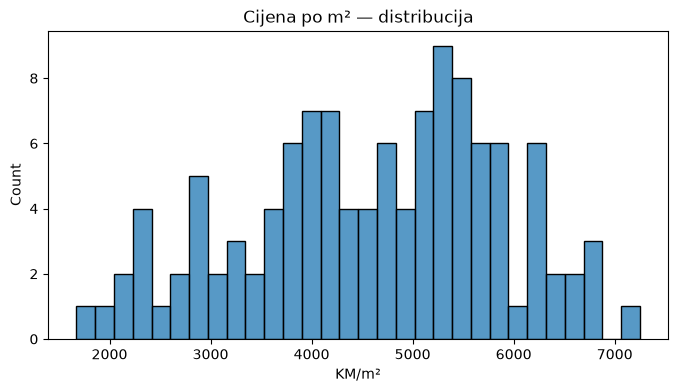

In [23]:
plt.figure(figsize=(8, 4))
# TODO: nacrtaj histogram kolone 'cijena_m2' iz df_clean, 30 binova
sns.histplot(df_clean['cijena_m2'], bins=30)
plt.title('Cijena po m² — distribucija')
plt.xlabel('KM/m²')
plt.show()

### 3b — Cijena/m² po fizičkom stanju stana (boxplot)

Koristimo `fizicko_stanje` (kolonu koju ste upravo napravili) umjesto sirove `stanje` kolone — tako namještenost ne miješa kategorije na grafu.

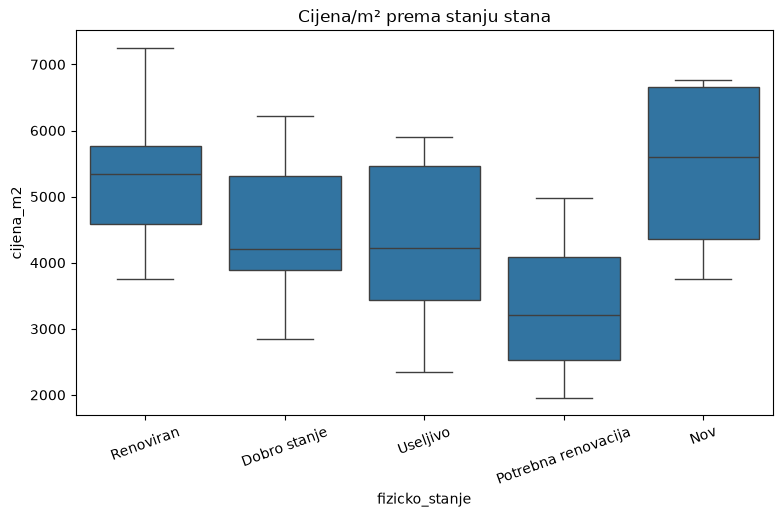

In [26]:
plt.figure(figsize=(9, 5))
# TODO: napravi boxplot - x='fizicko_stanje', y='cijena_m2', data=df_clean
sns.boxplot(data=df_clean, x='fizicko_stanje', y='cijena_m2')
plt.xticks(rotation=20)
plt.title('Cijena/m² prema stanju stana')
plt.show()

> **Usput — korelacija nije uzročnost.** Prije nego zaključite da nešto "uzrokuje" nešto drugo iz grafa, pitajte se: postoji li neki treći faktor koji objašnjava oboje?

## Korak 4 — Filtriranje i sortiranje
### 4a — 10 najskupljih stanova (po ukupnoj cijeni)

In [32]:
# TODO: sortiraj df_clean po 'cijena_km_clean' opadajuće, prikaži prvih 10
df_clean.sort_values('cijena_km_clean', ascending=False)[
    ['naselje_clean', 'kvadratura_clean', 'sprat_clean', 'stanje', 'cijena_km_clean']
].head(10)

,naselje_clean,kvadratura_clean,sprat_clean,stanje,cijena_km_clean
335,Mejdan,124.0,0.0,Renoviran,714700.0
40,Sjenjak,121.0,2.0,Useljivo,713500.0
114,Bukinje,156.0,6.0,Dobro stanje,636800.0
122,Centar,108.0,9.0,Useljivo,609500.0
142,Stupine,104.0,0.0,Namješten,531100.0
523,Simin Han,132.0,2.0,Nov,508300.0
632,Centar,72.0,3.0,Namješten,465100.0
188,Stupine,69.0,2.0,Nov,465000.0
106,Mejdan,83.0,1.0,Nenamješten,456300.0
66,Centar,79.0,10.0,Nenamješten,448900.0


### 4b — Prosječna cijena/m² po naselju (groupby)

In [33]:
# TODO: grupiši po 'naselje_clean', izračunaj prosjek 'cijena_m2', sortiraj opadajuće
df_clean.groupby('naselje_clean')['cijena_m2'].mean().sort_values(ascending=False).round(0)

naselje_clean
Centar            5857.0
Mejdan            5547.0
Brčanska Malta    5317.0
Stupine           5103.0
Slavinovići       5028.0
Sjenjak           4720.0
Kreka             4544.0
Irac              4344.0
Zlokovac          4204.0
Solina            3711.0
Dragodol          3669.0
Bukinje           3283.0
Šićki Brod        2923.0
Simin Han         2912.0
Gornja Tuzla      2349.0
Name: cijena_m2, dtype: float64

### Checkpoint 🎯
Prođite kratko sa parom: **šta vas je već sada iznenadilo u podacima?** Recite jednu rečenicu naglas.

## Izazov — Šta određuje cijenu stana?

**Zadatak:** pronađite jedan iznenađujući uvid o tome šta utiče na cijenu stana, i pripremite jedan graf koji to dokazuje + 1-2 rečenice objašnjenja (bez koda — obično jezik).

Ako ste zapele, probajte jedno od ovih pitanja:
- Da li veći stanovi imaju nižu ili višu cijenu po m² od manjih?
- Da li stanje stana (renovirano vs treba renovaciju) mijenja cijenu više nego lokacija?
- Da li sprat utiče na cijenu (prizemlje/najviši sprat vs srednji)?
- Ima li veze između godine izgradnje i cijene?

**Kako predstaviti graf (3 pravila):**
1. Naslov = poenta, ne opis ("Noviji stanovi su skuplji", ne "Cijena vs godina")
2. Ukloni sve što ne nosi informaciju (nepotrebne linije, boje, 3D efekte)
3. Istakni jednu stvar — ne pokušavaj reći sve na jednom grafu

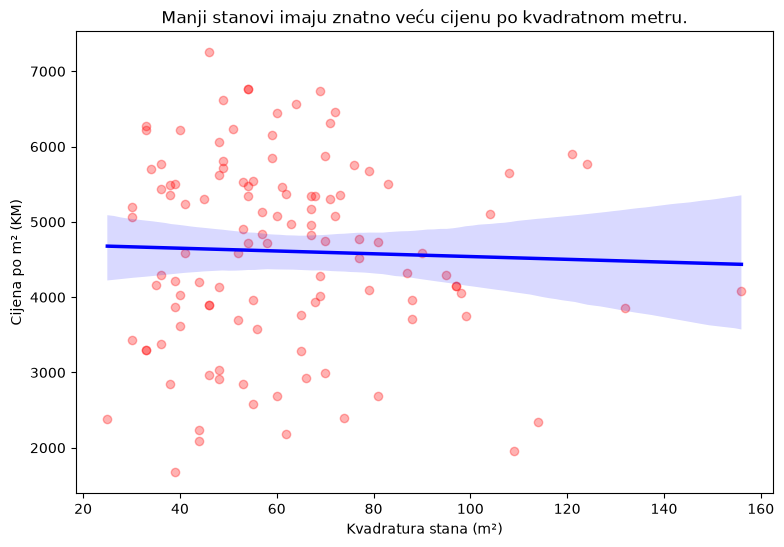

In [39]:
# TODO: vaš graf ovdje (scatter, boxplot ili heatmap - birajte prema pitanju koje istražujete)
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df_clean,
    x='kvadratura_clean',
    y='cijena_m2',
    scatter_kws={'alpha': 0.3, 'color': 'red'},
    line_kws={'color': 'blue', 'linewidth': 2.5},
)

plt.title(
    'Manji stanovi imaju znatno veću cijenu po kvadratnom metru.'
)
plt.xlabel('Kvadratura stana (m²)')
plt.ylabel('Cijena po m² (KM)')
plt.show()


## Prezentacija 🎤
60-90 sekundi po paru: pokažite graf, recite uvid naglas.

---
## Zadaća
**Dio 1:** Instalirajte VS Code + Jupyter ekstenziju, aktivirajte GitHub Copilot, i pokušajte proširiti današnju EDA vježbu uz njegovu pomoć. Zapišite: gdje vam je pomogao, gdje je predložio nešto pogrešno.

**Dio 2:** Pronađite (ili napravite) svoj dataset. Ponovite proces sa časa: učitajte, riješite bar 2 problema u podacima, napravite 2-3 grafa, napišite jedan pasus sa najzanimljivijim uvidom.

Vidimo se na Radionici 2 — hajmo vidjeti da li model može predvidjeti cijenu bolje od vas! 🚀